# Cholesky decomposition
## On Vanilla Cholesky decomposition
The idea behind Cholesky decomposition is to express a positive-definite symmetric matrix into the product of a lower triangular matrix with the transpose (or conjugate) of itself:
$$
A = LL^{T}
$$
It follows from an example such as:
$$
A =
\begin{pmatrix}
4 & 2 & 2 \\
2 & 5 & 1 \\
2 & 1 & 6
\end{pmatrix}
=
\begin{pmatrix}
a & 0 & 0 \\
b & d & 0 \\
c & e & f
\end{pmatrix}
\begin{pmatrix}
a & b & c \\
0 & d & e \\
0 & 0 & f
\end{pmatrix}
$$
It is possible to determine the values of each unknown elementwise. Starting from the diagonal element $a$:
$$
4 = a^2 \implies a = 2
$$
And then it follows that:
$$
2 = ab \implies b = 1
$$
$$
2 = ac \implies c = 1
$$
And we have the first Cholesky vector:
$$
L_0 =
\begin{pmatrix}
2 \\
1 \\
1
\end{pmatrix}
$$
Substituting on $L$, it is possible to continue this procedure, and in the end it results in that there are two ways to generally compute diagonal and non-diagonal elements of the $j^{th}$ Cholesky vectors:
$$
L_{jj} = \sqrt{A_{jj} - \sum_{k=1}^{j-1} L^2_{jk}}
$$
And:
$$
L_{ij} = \frac{1}{L_{jj}} \left(A_{ij} - \sum_{k=1}^{j-1} L_{ik}L_{jk}\right)
$$

So in this notebook we are going to start performing decomposition on matrices with this "vanilla" Cholesky decomposition, in order to prepare to decompose the ERI tensors.

---



In [1]:
from typing import Union

import numpy as np
from numpy.typing import NDArray

import matplotlib.pyplot as plt

from py_mods.src.SCF.plot_utilities import plot_map

plt.rcParams["font.family"] = "Times New Roman"

# Positive definite matrices
We need symmetric positive-definite matrices to decompose so we build the helper function:

In [2]:
def positive_definite_matrix(n: int, randseed: Union[None, int] = None) -> NDArray:
    if randseed is None:
        randseed = np.random.randint(0, 100)

    np.random.seed(randseed)

    B = np.random.randn(n, n)
    A = B @ B.T + np.eye(n) * 0.1

    return A

In [3]:
A = positive_definite_matrix(4)
A[2,1] = A[1,2] = 0.

In [4]:
def vanilla_cholesky(A: NDArray) -> NDArray:
    L = np.zeros_like(A)

    L[0, 0] = np.sqrt(A[0, 0])

    for j in range(0, len(A)):
        summation = np.sum(L[j, :j] ** 2)
        L[j, j] = np.sqrt(A[j, j] - summation)

        for i in range(j + 1, len(A)):
            summation = np.sum(L[i, :j] * L[j, :j])
            L[i, j] = (A[i, j] - summation) / L[j, j]

    return L

In [5]:
L = vanilla_cholesky(A)
print(L)
np.all((L@L.T - A) < 1E-15)

[[ 1.63821     0.          0.          0.        ]
 [-0.43599321  1.46191267  0.          0.        ]
 [-2.06069163 -0.61456992  0.39663033  0.        ]
 [-0.00666246  0.8280276   0.52967391  0.71598257]]


np.True_

In [6]:
ns = [5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 90, 100, 250, 300, 400, 500, 750, 1000, 1250, 1500, 2000, 2500, 3000]
errors = []
for n in ns:
    A_2 = positive_definite_matrix(n, randseed=67)
    L_2 = vanilla_cholesky(A_2)

    max_error = np.max(L_2 @ L_2.T - A_2)

    errors.append(max_error)

    print(f"Max of L@L.T-A for n={n:4}: {max_error:4e}")

Max of L@L.T-A for n=   5: 8.881784e-16
Max of L@L.T-A for n=  10: 1.776357e-15
Max of L@L.T-A for n=  15: 3.552714e-15
Max of L@L.T-A for n=  20: 7.105427e-15
Max of L@L.T-A for n=  25: 3.552714e-15
Max of L@L.T-A for n=  30: 7.105427e-15
Max of L@L.T-A for n=  40: 7.105427e-15
Max of L@L.T-A for n=  50: 2.131628e-14
Max of L@L.T-A for n=  60: 2.842171e-14
Max of L@L.T-A for n=  70: 1.421085e-14
Max of L@L.T-A for n=  90: 2.842171e-14
Max of L@L.T-A for n= 100: 5.684342e-14
Max of L@L.T-A for n= 250: 1.705303e-13
Max of L@L.T-A for n= 300: 2.273737e-13
Max of L@L.T-A for n= 400: 2.273737e-13
Max of L@L.T-A for n= 500: 3.410605e-13
Max of L@L.T-A for n= 750: 6.821210e-13
Max of L@L.T-A for n=1000: 6.821210e-13
Max of L@L.T-A for n=1250: 9.094947e-13
Max of L@L.T-A for n=1500: 1.136868e-12
Max of L@L.T-A for n=2000: 1.136868e-12
Max of L@L.T-A for n=2500: 1.818989e-12
Max of L@L.T-A for n=3000: 1.818989e-12


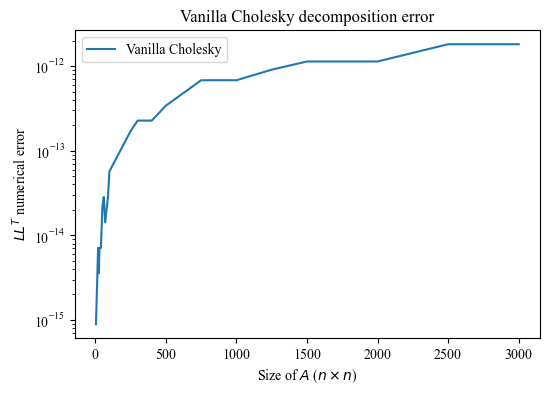

In [7]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(ns, errors, label="Vanilla Cholesky")
ax.set_yscale("log")
ax.set_title("Vanilla Cholesky decomposition error")
ax.set_xlabel("Size of $A$ ($n \\times n$)")
ax.set_ylabel(f"$LL^T$ numerical error")
ax.legend()
plt.show()

Which is slightly concerning, due to the size of ERI reduced matrix being of the order of $N_{bas}^{2}$ easily exceeding the $25 \times 25$ size. 

---

# Pivoted Cholesky decomposition

The pivoted Cholesky algorithm is different to the vanilla Cholesky decomposition in that a pivot element $A_{jj}$ is chosen, where this is the largest element of the diagonal. Then the $J^{th}$ vector will be defined as: 

$$
L_p^J = \frac{M_{pJ}}{\sqrt{M_{JJ}}}
$$

And the whole matrix is updated as: 

$$
M_{pq}^{(J)} = M_{pq}^{(J-1)} - L^J \otimes L^J
$$

Since the L vector will have the same dimension as the matrix. Lets try it out:

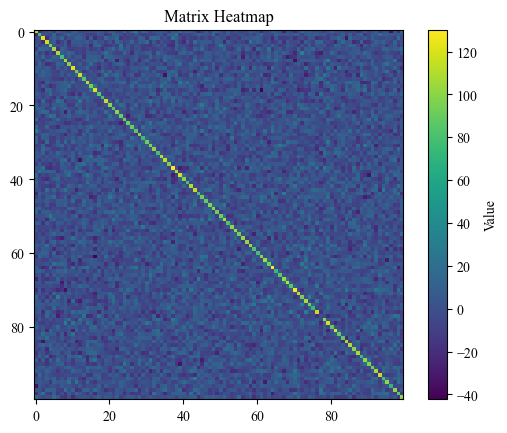

Tolerance reached
165.42567343222873


In [8]:
n = 100
A = positive_definite_matrix(n, randseed=3)

for i in range(0, int(0.9*n)):
    irand = np.random.randint(0,n)
    jrand = np.random.randint(0,n)
    A[irand,jrand] = A[jrand,irand] = 0
plot_map(A)
A_work = np.copy(A)

L_vectors = []
maxdiag= []

for i in range(0, n-4):
    pivot_index = np.argmax(np.diag(A_work))
    maxdiag.append(np.diag(A_work)[pivot_index])
    # print(pivot_index)
    if np.diag(A_work)[pivot_index] < 1:
        print("Tolerance reached")
        break
    L_temp = A_work[:, pivot_index] / np.sqrt(A_work[pivot_index, pivot_index])
    L_vectors.append(np.copy(L_temp))
    A_work -= np.outer(L_temp, L_temp)

L_vectors = np.vstack(L_vectors).T # store as columns

reconstructed = L_vectors @ L_vectors.T

# inv = np.argsort(perm)
# reconstructed = reconstructed[np.ix_(inv, inv)]


# plot_map(reconstructed)
print(np.max(reconstructed - A))

In [9]:
A_23 = L_vectors[2] @ L_vectors[3]
A_23


np.float64(-21.489196450354058)

In [10]:
A[2,3]

np.float64(-21.489196450354054)

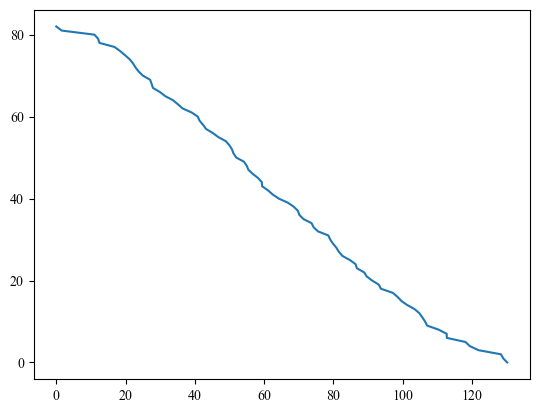

In [11]:
plt.plot(maxdiag, np.arange(0,len(maxdiag)))
plt.show()